# EXPLORATORIO

# Comportamiento de Fidelidad

# 0. Importaciones y Configuración

In [71]:
from astropy.io import fits
import astropy.units as u
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy import constants as const
import os

import sys

sys.path.append('../../src')

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'

## 0.1. Definición de funciones

In [117]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def chi_cuadrado(valor_observado, valor_referencia):
    mask = valor_referencia > 0
    return np.sum((valor_observado[mask] - valor_referencia[mask]) ** 2 / valor_referencia[mask])

def chi_cuadrado_m1(valor_observado, valor_referencia):
    return np.sum((np.abs(valor_observado) - np.abs(valor_referencia)) ** 2 / np.abs(valor_referencia))

def regresion_obs_ref(valor_observado, valor_referencia, incluir_cero=True):
    """
    Compara obs vs ref mediante regresion lineal: obs = a * ref + b.

    Separa tres efectos que el chi^2 mezcla o ignora:
      pendiente a : sesgo de flujo / ganancia (1.0 = flujo recuperado; a<1 = perdida)
      intercepto b: flujo espurio / offset sistematico (idealmente 0)
      r2          : fraccion de varianza explicada (fidelidad punto a punto)
      dispersion  : RMSE del residuo obs - (a*ref + b)

    incluir_cero=True usa todos los pixeles, de modo que los pixeles con ref=0
    hacen que el intercepto capture el flujo espurio fuera del soporte real.
    incluir_cero=False ajusta solo donde ref > 0 (comparable al chi^2 actual).
    """
    obs = np.asarray(valor_observado, dtype=float)
    ref = np.asarray(valor_referencia, dtype=float)

    if not incluir_cero:
        mask = ref > 0
        obs, ref = obs[mask], ref[mask]

    a, b = np.polyfit(ref, obs, 1)
    modelo = a * ref + b
    ss_res = np.sum((obs - modelo) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    dispersion = np.sqrt(np.mean((obs - modelo) ** 2))

    return {'pendiente': a, 'intercepto': b, 'r2': r2, 'dispersion': dispersion}

def recuperacion_por_brillo(valor_observado, valor_referencia, n_bins=12, ref_min=None):
    """
    Fraccion de flujo recuperado en funcion del brillo de la referencia.

    Agrupa los pixeles en bins log-espaciados segun ref y, en cada bin,
    calcula mediana(obs) / mediana(ref). Asi se ve si la emision DEBIL
    (que la pendiente global ignora por el rango dinamico) se recupera o no.

    ref_min: piso de brillo. Solo se binean pixeles con ref >= ref_min, para
             evitar el blow-up del cociente en bins donde ref -> 0 (alas del
             beam / no señal real). Si None, usa el minimo positivo de ref.

    Devuelve (centros_bin, recuperacion); recuperacion ~ 1 = flujo recuperado.
    """
    obs = np.asarray(valor_observado, dtype=float)
    ref = np.asarray(valor_referencia, dtype=float)

    mask = ref > 0
    if ref_min is not None:
        mask &= ref >= ref_min
    obs, ref = obs[mask], ref[mask]

    if ref.size == 0:
        return np.array([]), np.array([])

    bordes = np.logspace(np.log10(ref.min()), np.log10(ref.max()), n_bins + 1)
    idx = np.digitize(ref, bordes)

    centros, recuperacion = [], []
    for k in range(1, n_bins + 1):
        sel = idx == k
        if np.count_nonzero(sel) == 0:
            continue
        ref_med = np.median(ref[sel])
        if ref_med == 0:
            continue
        centros.append(ref_med)
        recuperacion.append(np.median(obs[sel]) / ref_med)
    return np.array(centros), np.array(recuperacion)

def factores_mas_cuadrado(N):
    a = math.isqrt(N)  # piso de la raíz cuadrada
    while N % a != 0:
        a -= 1
    b = N // a
    return a, b

def cargar_momentos_log(subdir, momento_idx, umbral_inicial, umbral_step, cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, CUBE_DIR, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento).flatten())
    return momentos

def flux_max(cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

## 0.2. Parámetros Matplotlib

In [73]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})

# 1. Cube Isolated

## 1.1. Isolated AC5

In [90]:
CUBE_DIR = 'isolated_sub_AC5_N50_width1'

### 1.1.1. Apertura Momentos de Referencia

In [91]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment0_AC5.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment1_AC5.fits'))
moment_1_ref = np.squeeze(hdu[0].data)
moment_1_ref_flat = np.nan_to_num(moment_1_ref).flatten()


hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment2_AC5.fits'))
moment_2_ref = np.squeeze(hdu[0].data)

### 1.1.2. Steps y Cantidad de Cubos

In [104]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

momentos_0_noisy  = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub', CUBE_DIR)
momentos_0_soft_8 = cargar_momentos_log('moments_soft_8', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_8', CUBE_DIR)
momentos_0_soft_7 = cargar_momentos_log('moments_soft_7', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_7', CUBE_DIR)
momentos_0_soft_6 = cargar_momentos_log('moments_soft_6', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_6', CUBE_DIR)
momentos_0_soft_5 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR)
momentos_0_soft_4 = cargar_momentos_log('moments_soft_4', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_4', CUBE_DIR)
momentos_0_soft_3 = cargar_momentos_log('moments_soft_3', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_3', CUBE_DIR)
momentos_0_soft_2 = cargar_momentos_log('moments_soft_2', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_2', CUBE_DIR)
momentos_0_soft_1 = cargar_momentos_log('moments_soft_1', 0, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_1', CUBE_DIR)

### 1.1.3. Momentos 0

In [105]:
flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_8', CUBE_DIR)
umbrales_soft_8 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_7', CUBE_DIR)
umbrales_soft_7 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_6', CUBE_DIR)
umbrales_soft_6 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR)
umbrales_soft_5 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_4', CUBE_DIR)
umbrales_soft_4 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_3', CUBE_DIR)
umbrales_soft_3 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_2', CUBE_DIR)
umbrales_soft_2 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_1', CUBE_DIR)
umbrales_soft_1 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC5_N50_width1_noisy_sub', CUBE_DIR)
umbrales_noisy = umbrales_log(flux_max_val, IterativeMin, IterativeStep)


#### 1.1.3.A. RMSE

In [78]:
rmse_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_5.append(rmse_momento_0)

rmse_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_4.append(rmse_momento_0)

rmse_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_3.append(rmse_momento_0)

rmse_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_2.append(rmse_momento_0)

rmse_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_1.append(rmse_momento_0)

rmse_momentos_0_noisy = []
for momento in momentos_0_noisy:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_noisy.append(rmse_momento_0)


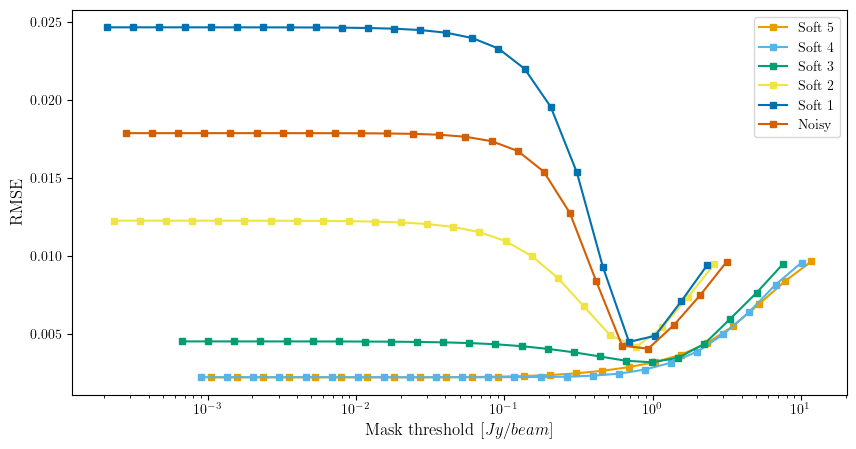

In [81]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_ajustado, rmse_momentos_0_soft_5, ms=5, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4_ajustado, rmse_momentos_0_soft_4, ms=5, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3_ajustado, rmse_momentos_0_soft_3, ms=5, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2_ajustado, rmse_momentos_0_soft_2, ms=5, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1_ajustado, rmse_momentos_0_soft_1, ms=5, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy_ajustado, rmse_momentos_0_noisy, ms=5, label='Noisy', marker='s')

plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()


#### 1.1.3.B. Chi Cuadrado

In [106]:
chi_cuadrado_momentos_0_soft_8 = []
for momento in momentos_0_soft_8:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_8.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_7 = []
for momento in momentos_0_soft_7:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_7.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_6 = []
for momento in momentos_0_soft_6:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_6.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_5.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_4.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_3.append(chi_cuadrado_momento_0)
    
chi_cuadrado_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_2.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_1.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_noisy = []
for momento in momentos_0_noisy:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_noisy.append(chi_cuadrado_momento_0)


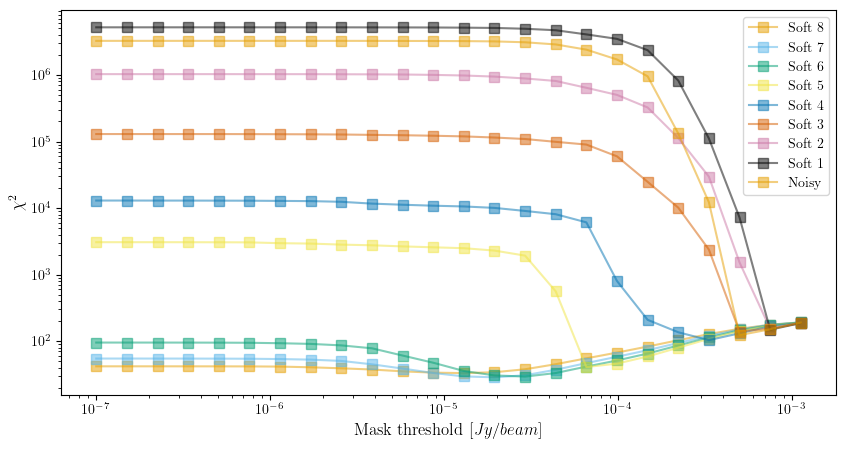

In [107]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_8, chi_cuadrado_momentos_0_soft_8, ms=7, label='Soft 8', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_7, chi_cuadrado_momentos_0_soft_7, ms=7, label='Soft 7', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_6, chi_cuadrado_momentos_0_soft_6, ms=7, label='Soft 6', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_5, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_4, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_3, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_2, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s', alpha=0.5)
plt.errorbar(umbrales_soft_1, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s', alpha=0.5)
plt.errorbar(umbrales_noisy, chi_cuadrado_momentos_0_noisy, ms=7, label='Noisy', marker='s', alpha=0.5)



plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [84]:
BK_NOISY = 3.56e-4
BK_SOFT_5 = 9.55e-5
BK_SOFT_4 = 1.11e-4
BK_SOFT_3 = 1.49e-4
BK_SOFT_2 = 4.30e-4
BK_SOFT_1 = 4.80e-4

umbrales_noisy_ajustado = umbrales_noisy / BK_NOISY
umbrales_soft_5_ajustado = umbrales_soft_5 / BK_SOFT_5
umbrales_soft_4_ajustado = umbrales_soft_4 / BK_SOFT_4
umbrales_soft_3_ajustado = umbrales_soft_3 / BK_SOFT_3
umbrales_soft_2_ajustado = umbrales_soft_2 / BK_SOFT_2
umbrales_soft_1_ajustado = umbrales_soft_1 / BK_SOFT_1

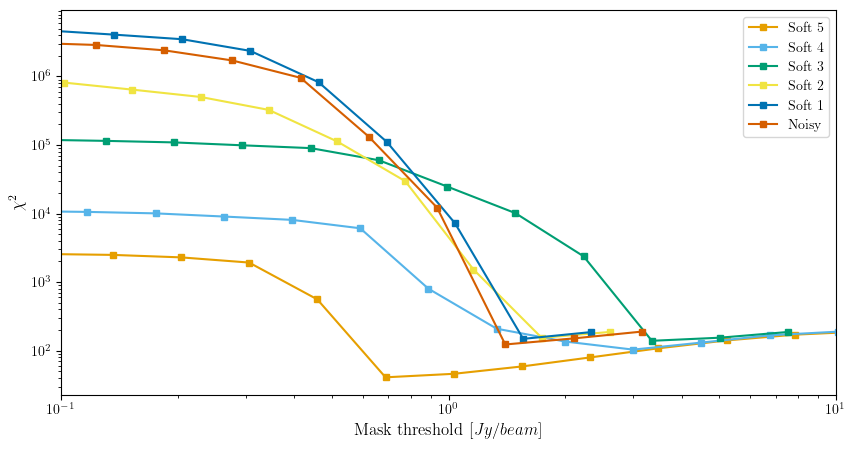

In [88]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_ajustado, chi_cuadrado_momentos_0_soft_5, ms=5, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4_ajustado, chi_cuadrado_momentos_0_soft_4, ms=5, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3_ajustado, chi_cuadrado_momentos_0_soft_3, ms=5, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2_ajustado, chi_cuadrado_momentos_0_soft_2, ms=5, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1_ajustado, chi_cuadrado_momentos_0_soft_1, ms=5, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy_ajustado, chi_cuadrado_momentos_0_noisy, ms=5, label='Noisy', marker='s')


plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-1, 1e1)
plt.legend()

Text(0.5, 1.0, '$\\chi^2$ moment-0')

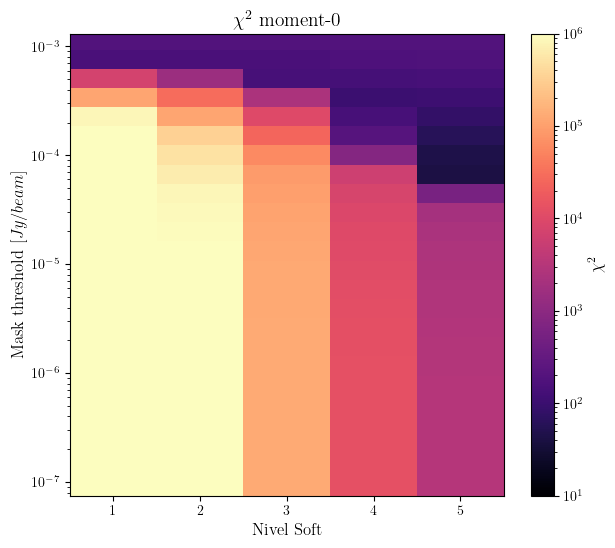

In [536]:
import matplotlib as mpl

niveles_soft = [1, 2, 3, 4, 5]
chi_cuadrado_por_soft = [
    chi_cuadrado_momentos_0_soft_1,
    chi_cuadrado_momentos_0_soft_2,
    chi_cuadrado_momentos_0_soft_3,
    chi_cuadrado_momentos_0_soft_4,
    chi_cuadrado_momentos_0_soft_5,
]
umbrales_por_soft = [
    umbrales_soft_1,
    umbrales_soft_2,
    umbrales_soft_3,
    umbrales_soft_4,
    umbrales_soft_5,
]

umbrales_ref = max(umbrales_por_soft, key=len)

chi_matrix = np.full((len(umbrales_ref), len(niveles_soft)), np.nan)
for col, chi in enumerate(chi_cuadrado_por_soft):
    chi_matrix[:len(chi), col] = chi

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(
    niveles_soft, umbrales_ref, chi_matrix,
    shading='nearest',
    norm=mpl.colors.LogNorm(vmin=10, vmax=10e5),
    cmap='magma',
)
plt.colorbar(mesh, label=r'$\chi^2$')
plt.xlabel('Nivel Soft')
plt.ylabel(r'Mask threshold [$Jy/beam$]')
plt.yscale('log')
plt.xticks(niveles_soft)
plt.title(r'$\chi^2$ moment-0', fontsize=14)

#### 1.1.3.C Regresión obs vs ref

In [114]:
# momentos_0_soft_N es una LISTA de mapas (uno por umbral de mascara),
# asi que la regresion se aplica mapa por mapa recorriendo los umbrales.
momentos_por_soft = {
    'Soft 8': (umbrales_soft_8, momentos_0_soft_8),
    'Soft 7': (umbrales_soft_7, momentos_0_soft_7),
    'Soft 6': (umbrales_soft_6, momentos_0_soft_6),
    'Soft 5': (umbrales_soft_5, momentos_0_soft_5),
    'Soft 4': (umbrales_soft_4, momentos_0_soft_4),
    'Soft 3': (umbrales_soft_3, momentos_0_soft_3),
    'Soft 2': (umbrales_soft_2, momentos_0_soft_2),
    'Soft 1': (umbrales_soft_1, momentos_0_soft_1),
    'Noisy':  (umbrales_noisy,  momentos_0_noisy),
}

def _curvas_regresion(incluir_cero):
    salida = {}
    for nombre, (umbrales, momentos) in momentos_por_soft.items():
        diags = [regresion_obs_ref(m, moment_0_ref_flat, incluir_cero=incluir_cero)
                 for m in momentos]
        salida[nombre] = {
            'umbrales':   umbrales,
            'pendiente':  [d['pendiente']  for d in diags],
            'intercepto': [d['intercepto'] for d in diags],
            'r2':         [d['r2']         for d in diags],
            'dispersion': [d['dispersion'] for d in diags],
        }
    return salida

# regresion_por_soft[True]  -> ajuste con todos los pixeles (intercepto = flujo espurio)
# regresion_por_soft[False] -> ajuste solo donde ref > 0 (comparable al chi^2)
regresion_por_soft = {
    True:  _curvas_regresion(incluir_cero=True),
    False: _curvas_regresion(incluir_cero=False),
}


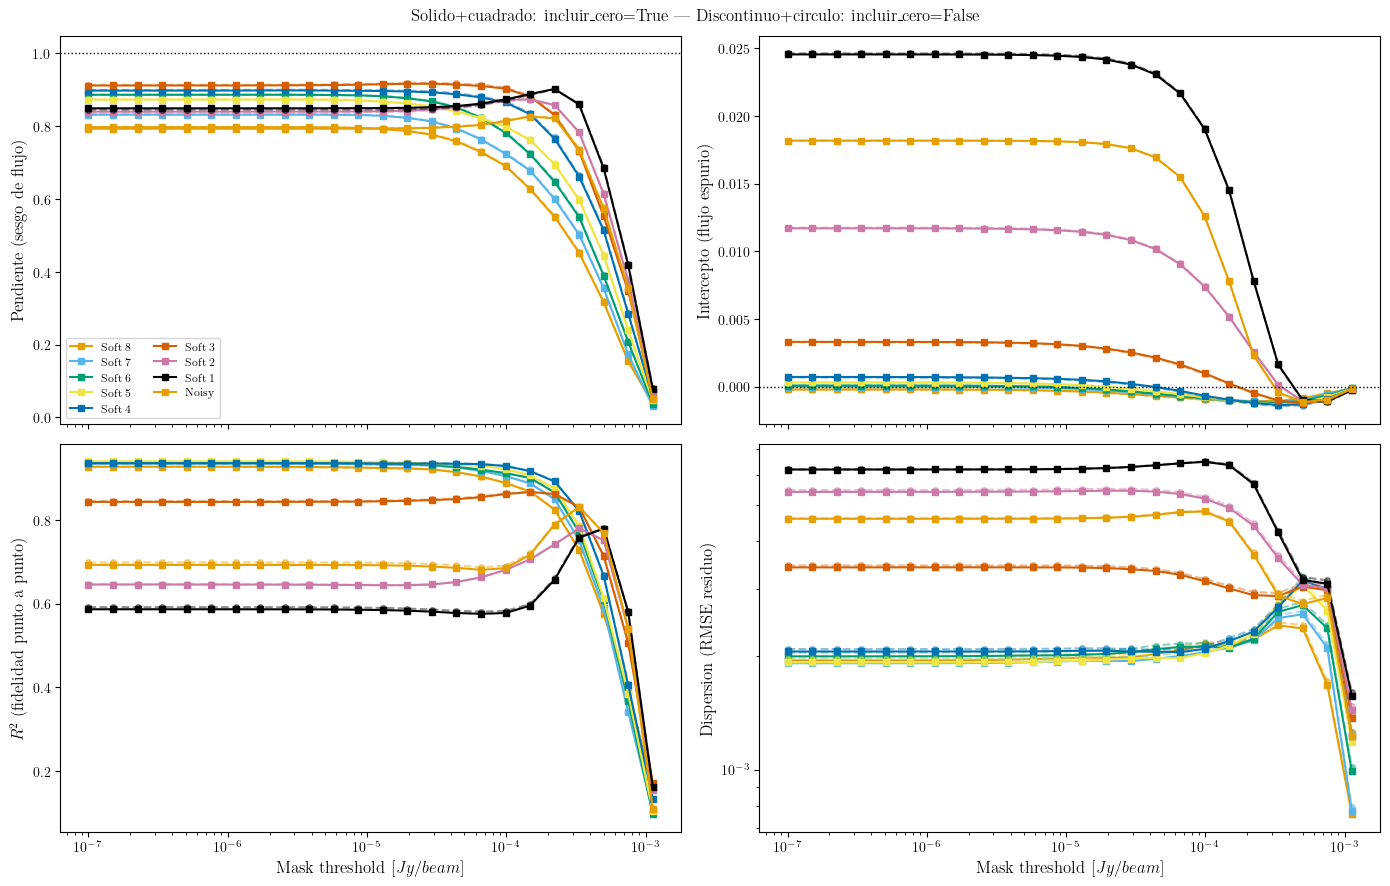

In [115]:
diagnosticos = ['pendiente', 'intercepto', 'r2', 'dispersion']
titulos = {
    'pendiente':  'Pendiente (sesgo de flujo)',
    'intercepto': 'Intercepto (flujo espurio)',
    'r2':         '$R^2$ (fidelidad punto a punto)',
    'dispersion': 'Dispersion (RMSE residuo)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, diag in zip(axes.flat, diagnosticos):
    for nombre in momentos_por_soft:
        c_con = regresion_por_soft[True][nombre]   # solido + cuadrado
        c_sin = regresion_por_soft[False][nombre]  # discontinuo + circulo
        linea, = ax.plot(c_con['umbrales'], c_con[diag], marker='s', ms=5, label=nombre)
        ax.plot(c_sin['umbrales'], c_sin[diag], marker='o', ms=4, ls='--',
                color=linea.get_color(), alpha=0.45)
    ax.set_ylabel(titulos[diag])
    ax.set_xscale('log')
    if diag == 'pendiente':
        ax.axhline(1.0, ls=':', color='k', lw=1)
    if diag == 'intercepto':
        ax.axhline(0.0, ls=':', color='k', lw=1)
    if diag == 'dispersion':
        ax.set_yscale('log')

for ax in axes[1]:
    ax.set_xlabel('Mask threshold [$Jy/beam$]')
axes[0, 0].legend(ncol=2, fontsize=8)
fig.suptitle('Solido+cuadrado: incluir_cero=True   |   Discontinuo+circulo: incluir_cero=False')
fig.tight_layout()

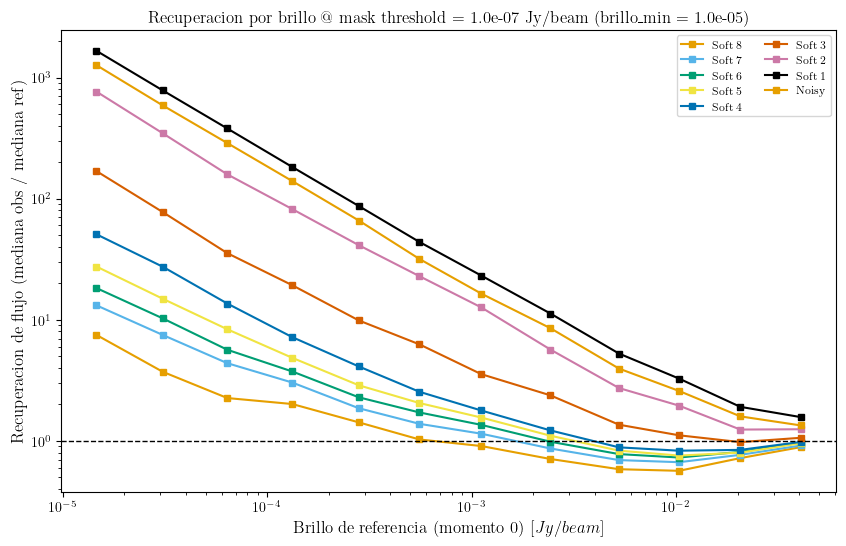

In [118]:
# Recuperacion de flujo vs brillo, para ver si la emision DEBIL sobrevive
# (la pendiente global la dominan los pixeles brillantes).
# idx_umbral=0 -> mask threshold mas bajo (1e-7): zona de plateau y comparable
# entre niveles, porque umbrales_log arranca siempre en IterativeMin.
#
# brillo_min: piso de brillo para evitar el blow-up del cociente donde ref->0
# (alas del beam, no señal real). Sube/baja este valor para acotar al rango
# de emision genuina.
idx_umbral = 0
brillo_min = 1e-5  # Jy/beam

plt.figure(figsize=(10, 6))
for nombre, (umbrales, momentos) in momentos_por_soft.items():
    centros, recup = recuperacion_por_brillo(
        momentos[idx_umbral], moment_0_ref_flat, n_bins=12, ref_min=brillo_min)
    plt.plot(centros, recup, marker='s', ms=5, label=nombre)
plt.axhline(1.0, ls='--', color='k', lw=1)  # recuperacion perfecta
plt.xlabel('Brillo de referencia (momento 0) [$Jy/beam$]')
plt.ylabel('Recuperacion de flujo (mediana obs / mediana ref)')
plt.xscale('log')
plt.yscale('log')  # los puntos con cociente <= 0 se omiten automaticamente
plt.title(f'Recuperacion por brillo @ mask threshold = {umbrales_soft_6[idx_umbral]:.1e} Jy/beam'
          f'  (brillo_min = {brillo_min:.1e})')
plt.legend(ncol=2, fontsize=8)

### 1.1.4. Momentos 1

In [537]:
momentos_1_noisy  = cargar_momentos_log('moments_noisy', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub', CUBE_DIR)
momentos_1_soft_5 = cargar_momentos_log('moments_soft_5', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR)
momentos_1_soft_4 = cargar_momentos_log('moments_soft_4', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_4', CUBE_DIR)
momentos_1_soft_3 = cargar_momentos_log('moments_soft_3', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_3', CUBE_DIR)
momentos_1_soft_2 = cargar_momentos_log('moments_soft_2', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_2', CUBE_DIR)
momentos_1_soft_1 = cargar_momentos_log('moments_soft_1', 1, IterativeMin, IterativeStep, 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_1', CUBE_DIR)

#### 1.1.4.A RMSE

In [538]:
rmse_momentos_1_soft_5 = []
for momento in momentos_1_soft_5:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_soft_5.append(rmse_momento_1)

rmse_momentos_1_soft_4 = []
for momento in momentos_1_soft_4:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_soft_4.append(rmse_momento_1)

rmse_momentos_1_soft_3 = []
for momento in momentos_1_soft_3:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_soft_3.append(rmse_momento_1)

rmse_momentos_1_soft_2 = []
for momento in momentos_1_soft_2:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_soft_2.append(rmse_momento_1)

rmse_momentos_1_soft_1 = []
for momento in momentos_1_soft_1:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_soft_1.append(rmse_momento_1)

rmse_momentos_1_noisy = []
for momento in momentos_1_noisy:
    rmse_momento_1 = rmse(momento, moment_1_ref_flat)
    rmse_momentos_1_noisy.append(rmse_momento_1)


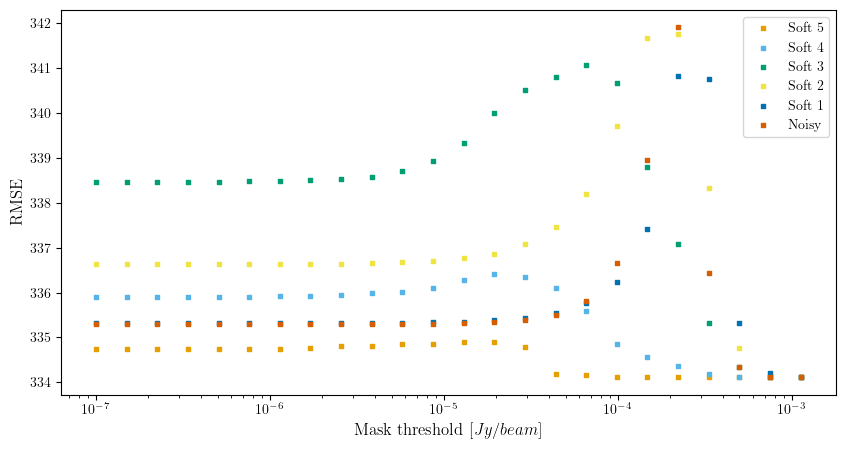

In [539]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, rmse_momentos_1_soft_5, s=10, label='Soft 5', marker='s')
plt.scatter(umbrales_soft_4, rmse_momentos_1_soft_4, s=10, label='Soft 4', marker='s')
plt.scatter(umbrales_soft_3, rmse_momentos_1_soft_3, s=10, label='Soft 3', marker='s')
plt.scatter(umbrales_soft_2, rmse_momentos_1_soft_2, s=10, label='Soft 2', marker='s')
plt.scatter(umbrales_soft_1, rmse_momentos_1_soft_1, s=10, label='Soft 1', marker='s')
plt.scatter(umbrales_noisy, rmse_momentos_1_noisy, s=10, label='Noisy', marker='s')

plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()

#### 1.1.4.B Chi Cuadrado

In [540]:
chi_cuadrado_momentos_1_soft_5 = []
for momento in momentos_1_soft_5:
    chi_cuadrado_momento_1 = chi_cuadrado(momento, moment_1_ref_flat)
    chi_cuadrado_momentos_1_soft_5.append(chi_cuadrado_momento_1)

chi_cuadrado_momentos_1_soft_4 = []
for momento in momentos_1_soft_4:
    chi_cuadrado_momento_1 = chi_cuadrado(momento, moment_1_ref_flat)
    chi_cuadrado_momentos_1_soft_4.append(chi_cuadrado_momento_1)

chi_cuadrado_momentos_1_soft_3 = []
for momento in momentos_1_soft_3:
    chi_cuadrado_momento_1 = chi_cuadrado(momento, moment_1_ref_flat)
    chi_cuadrado_momentos_1_soft_3.append(chi_cuadrado_momento_1)

chi_cuadrado_momentos_1_soft_2 = []
for momento in momentos_1_soft_2:
    chi_cuadrado_momento_1 = chi_cuadrado(momento, moment_1_ref_flat)
    chi_cuadrado_momentos_1_soft_2.append(chi_cuadrado_momento_1)

chi_cuadrado_momentos_1_soft_1 = []
for momento in momentos_1_soft_1:
    chi_cuadrado_momento_1 = chi_cuadrado(momento, moment_1_ref_flat)
    chi_cuadrado_momentos_1_soft_1.append(chi_cuadrado_momento_1)


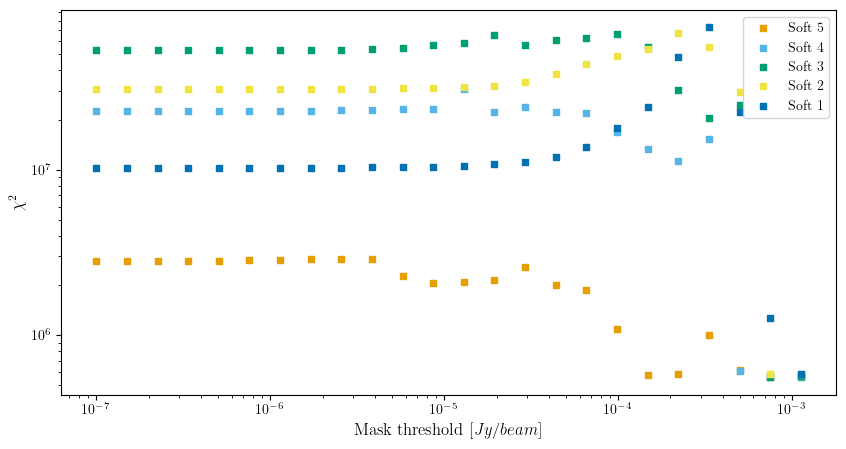

In [541]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, chi_cuadrado_momentos_1_soft_5, s=15, label='Soft 5', marker='s')
plt.scatter(umbrales_soft_4, chi_cuadrado_momentos_1_soft_4, s=15, label='Soft 4', marker='s')
plt.scatter(umbrales_soft_3, chi_cuadrado_momentos_1_soft_3, s=15, label='Soft 3', marker='s')
plt.scatter(umbrales_soft_2, chi_cuadrado_momentos_1_soft_2, s=15, label='Soft 2', marker='s')
plt.scatter(umbrales_soft_1, chi_cuadrado_momentos_1_soft_1, s=15, label='Soft 1', marker='s')
#plt.scatter(umbrales_noisy, chi_cuadrado_momentos_0_noisy, s=12, label='Noisy', marker='s')

plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

## 1.2. Isolated AC4

In [27]:
CUBE_DIR = 'isolated_sub_AC4_N50_width1'

### 1.2.1. Apertura Momentos de Referencia

In [28]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment0_AC4.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment1_AC4.fits'))
moment_1_ref = np.squeeze(hdu[0].data)
moment_1_ref_flat = np.nan_to_num(moment_1_ref).flatten()


hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment2_AC4.fits'))
moment_2_ref = np.squeeze(hdu[0].data)

### 1.2.2. Momentos 0

In [37]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

momentos_0_noisy  = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub', CUBE_DIR)
momentos_0_soft_5 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR)
momentos_0_soft_4 = cargar_momentos_log('moments_soft_4', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_4', CUBE_DIR)
momentos_0_soft_3 = cargar_momentos_log('moments_soft_3', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_3', CUBE_DIR)
momentos_0_soft_2 = cargar_momentos_log('moments_soft_2', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_2', CUBE_DIR)
momentos_0_soft_1 = cargar_momentos_log('moments_soft_1', 0, IterativeMin, IterativeStep, 'isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_1', CUBE_DIR)

In [41]:
flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR)
umbrales_soft_5 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_4', CUBE_DIR)
umbrales_soft_4 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_3', CUBE_DIR)
umbrales_soft_3 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_2', CUBE_DIR)
umbrales_soft_2 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub_wavelets_iterative_soft_1', CUBE_DIR)
umbrales_soft_1 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC4_N50_width1_noisy_sub', CUBE_DIR)
umbrales_noisy = umbrales_log(flux_max_val, IterativeMin, IterativeStep)



#### 1.2.2.A. RMSE

In [42]:
rmse_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_5.append(rmse_momento_0)

rmse_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_4.append(rmse_momento_0)

rmse_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_3.append(rmse_momento_0)

rmse_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_2.append(rmse_momento_0)

rmse_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_1.append(rmse_momento_0)

rmse_momentos_0_noisy = []
for momento in momentos_0_noisy:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_noisy.append(rmse_momento_0)
    

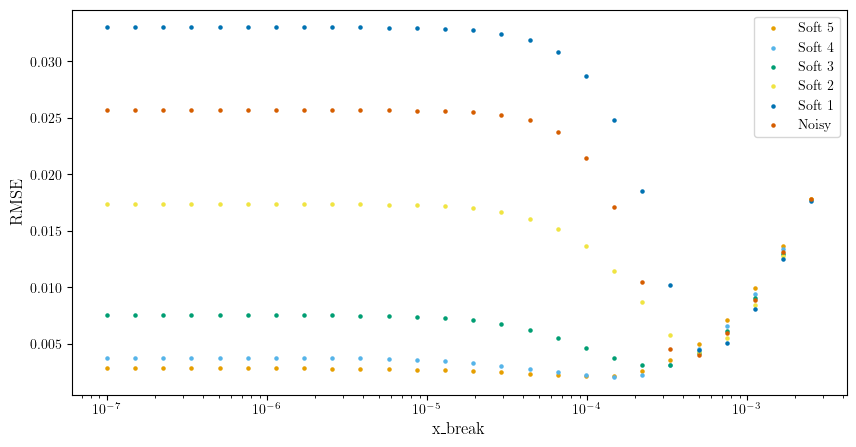

In [43]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, rmse_momentos_0_soft_5, s=5, label='Soft 5')
plt.scatter(umbrales_soft_4, rmse_momentos_0_soft_4, s=5, label='Soft 4')
plt.scatter(umbrales_soft_3, rmse_momentos_0_soft_3, s=5, label='Soft 3')
plt.scatter(umbrales_soft_2, rmse_momentos_0_soft_2, s=5, label='Soft 2')
plt.scatter(umbrales_soft_1, rmse_momentos_0_soft_1, s=5, label='Soft 1')
plt.scatter(umbrales_noisy, rmse_momentos_0_noisy, s=5, label='Noisy')
plt.xlabel('x_break')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()

#### 1.2.2.B. Chi Cuadrado

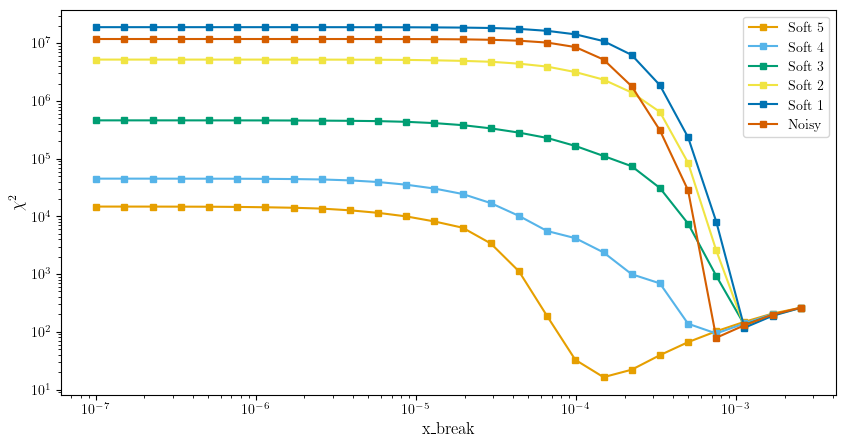

In [48]:
chi_cuadrado_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_5.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_4.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_3.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_2.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_1.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_noisy = []
for momento in momentos_0_noisy:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_noisy.append(chi_cuadrado_momento_0)

plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5, chi_cuadrado_momentos_0_soft_5, ms=5, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4, chi_cuadrado_momentos_0_soft_4, ms=5, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3, chi_cuadrado_momentos_0_soft_3, ms=5, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2, chi_cuadrado_momentos_0_soft_2, ms=5, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1, chi_cuadrado_momentos_0_soft_1, ms=5, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy, chi_cuadrado_momentos_0_noisy, ms=5, label='Noisy', marker='s')
plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [49]:
BK_NOISY = 4.38e-4
BK_SOFT_5 = 1.69e-4
BK_SOFT_4 = 1.63e-4
BK_SOFT_3 = 2.04e-4
BK_SOFT_2 = 5.05e-4
BK_SOFT_1 = 5.74e-4

umbrales_noisy_ajustado = umbrales_noisy / BK_NOISY
umbrales_soft_5_ajustado = umbrales_soft_5 / BK_SOFT_5
umbrales_soft_4_ajustado = umbrales_soft_4 / BK_SOFT_4
umbrales_soft_3_ajustado = umbrales_soft_3 / BK_SOFT_3
umbrales_soft_2_ajustado = umbrales_soft_2 / BK_SOFT_2
umbrales_soft_1_ajustado = umbrales_soft_1 / BK_SOFT_1

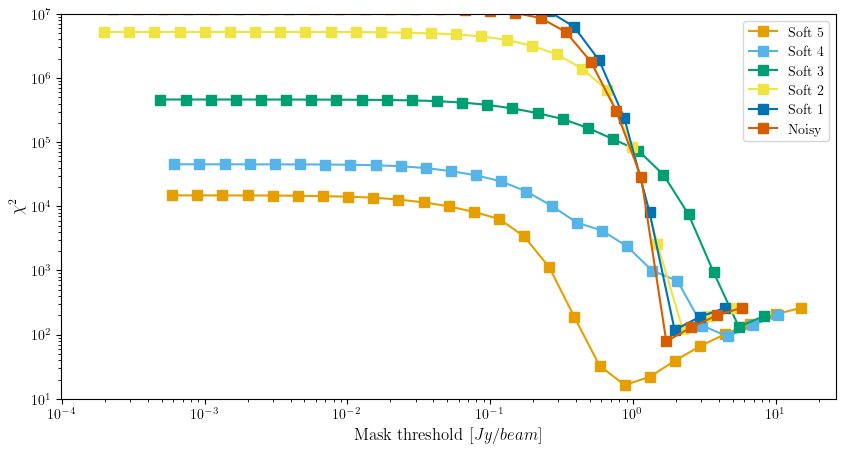

In [52]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_ajustado, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4_ajustado, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3_ajustado, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2_ajustado, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1_ajustado, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy_ajustado, chi_cuadrado_momentos_0_noisy, ms=7, label='Noisy', marker='s')


plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.ylim(10, 10e6)
plt.legend()

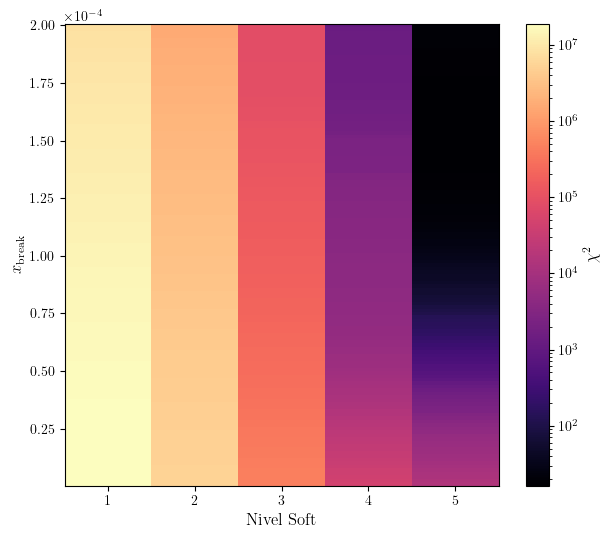

In [129]:
import matplotlib as mpl

niveles_soft = [1, 2, 3, 4, 5]
chi_cuadrado_por_soft = [
    chi_cuadrado_momentos_0_soft_1,
    chi_cuadrado_momentos_0_soft_2,
    chi_cuadrado_momentos_0_soft_3,
    chi_cuadrado_momentos_0_soft_4,
    chi_cuadrado_momentos_0_soft_5,
]

chi_matrix = np.array(chi_cuadrado_por_soft).T

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(
    niveles_soft, umbrales, chi_matrix,
    shading='nearest',
    norm=mpl.colors.LogNorm(),
    cmap='magma',
)
plt.colorbar(mesh, label=r'$\chi^2$')
plt.xlabel('Nivel Soft')
plt.ylabel(r'$x_{\mathrm{break}}$')
plt.xticks(niveles_soft)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

## 1.3. Isolated AC3

In [53]:
CUBE_DIR = 'isolated_sub_AC3_N50_width1'

### 1.3.1. Apertura Momentos de Referencia

In [54]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment0_AC3.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment1_AC3.fits'))
moment_1_ref = np.squeeze(hdu[0].data)
moment_1_ref_flat = np.nan_to_num(moment_1_ref).flatten()


hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment2_AC3.fits'))
moment_2_ref = np.squeeze(hdu[0].data)

### 1.3.2. Momentos 0

In [55]:
def cargar_momentos_log(subdir, momento_idx, umbral_inicial, umbral_step, cubo):
    hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, CUBE_DIR, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento).flatten())
    return momentos

def flux_max(cubo):
    hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

In [56]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

momentos_0_noisy  = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub')
momentos_0_soft_5 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_5')
momentos_0_soft_4 = cargar_momentos_log('moments_soft_4', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_4')
momentos_0_soft_3 = cargar_momentos_log('moments_soft_3', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_3')
momentos_0_soft_2 = cargar_momentos_log('moments_soft_2', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_2')
momentos_0_soft_1 = cargar_momentos_log('moments_soft_1', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_1')

In [57]:
flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_5')
umbrales_soft_5 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_4')
umbrales_soft_4 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_3')
umbrales_soft_3 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_2')
umbrales_soft_2 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_1')
umbrales_soft_1 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub')
umbrales_noisy = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

#### 1.3.2.A. RMSE

In [58]:
rmse_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_5.append(rmse_momento_0)

rmse_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_4.append(rmse_momento_0)

rmse_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_3.append(rmse_momento_0)

rmse_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_2.append(rmse_momento_0)

rmse_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_1.append(rmse_momento_0)

rmse_momentos_0_noisy = []
for momento in momentos_0_noisy:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_noisy.append(rmse_momento_0)


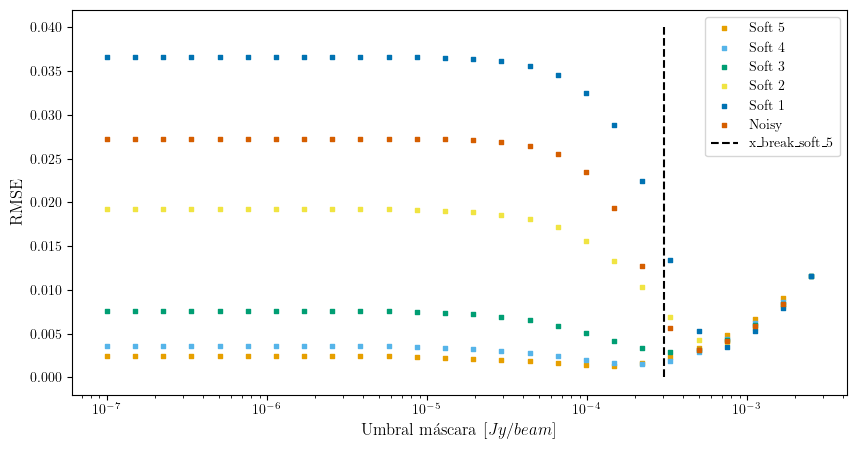

In [59]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, rmse_momentos_0_soft_5, s=10, label='Soft 5', marker='s')
plt.scatter(umbrales_soft_4, rmse_momentos_0_soft_4, s=10, label='Soft 4', marker='s')
plt.scatter(umbrales_soft_3, rmse_momentos_0_soft_3, s=10, label='Soft 3', marker='s')
plt.scatter(umbrales_soft_2, rmse_momentos_0_soft_2, s=10, label='Soft 2', marker='s')
plt.scatter(umbrales_soft_1, rmse_momentos_0_soft_1, s=10, label='Soft 1', marker='s')
plt.scatter(umbrales_noisy, rmse_momentos_0_noisy, s=10, label='Noisy', marker='s')

plt.vlines(3.05e-4, 0, 0.04, color='black', linestyle='--', label='x_break_soft_5')

plt.xlabel('Umbral máscara [$Jy/beam$]')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()

#### 1.3.2.B. Chi Cuadrado

In [60]:
chi_cuadrado_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_5.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_4.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_3.append(chi_cuadrado_momento_0)
    
chi_cuadrado_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_2.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_1.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_noisy = []
for momento in momentos_0_noisy:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_noisy.append(chi_cuadrado_momento_0)


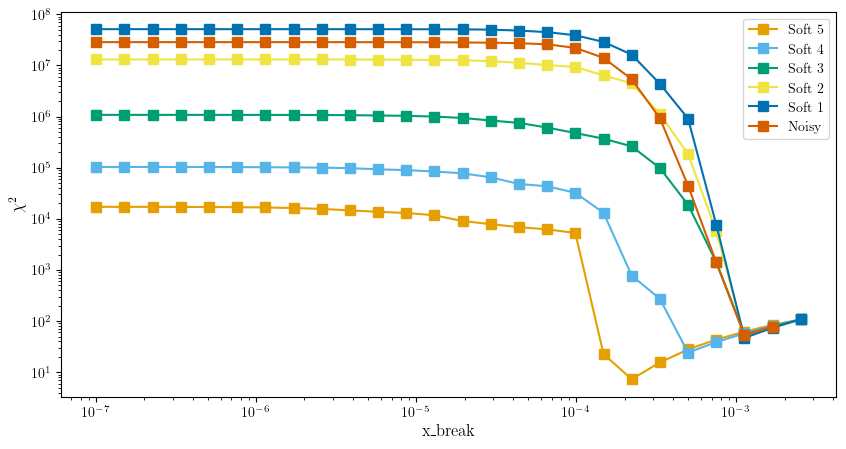

In [61]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy, chi_cuadrado_momentos_0_noisy, ms=7, label='Noisy', marker='s')

plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [62]:
BK_NOISY = 5.68e-4
BK_SOFT_5 = 3.05e-4
BK_SOFT_4 = 3.93e-4
BK_SOFT_3 = 4.84e-4
BK_SOFT_2 = 8.89e-4
BK_SOFT_1 = 7.28e-4

umbrales_noisy_ajustado = umbrales_noisy / BK_NOISY
umbrales_soft_5_ajustado = umbrales_soft_5 / BK_SOFT_5
umbrales_soft_4_ajustado = umbrales_soft_4 / BK_SOFT_4
umbrales_soft_3_ajustado = umbrales_soft_3 / BK_SOFT_3
umbrales_soft_2_ajustado = umbrales_soft_2 / BK_SOFT_2
umbrales_soft_1_ajustado = umbrales_soft_1 / BK_SOFT_1

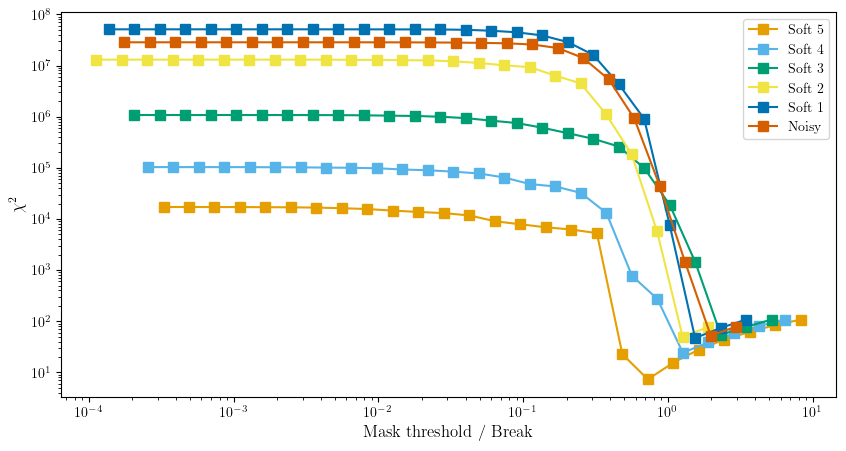

In [65]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_ajustado, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4_ajustado, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3_ajustado, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2_ajustado, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1_ajustado, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy_ajustado, chi_cuadrado_momentos_0_noisy, ms=7, label='Noisy', marker='s')


plt.xlabel('Mask threshold / Break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

([<matplotlib.axis.XTick at 0x12c39cca0>,
 [Text(1, 0, '$\\mathdefault{1}$'),
  Text(2, 0, '$\\mathdefault{2}$'),
  Text(3, 0, '$\\mathdefault{3}$'),
  Text(4, 0, '$\\mathdefault{4}$'),
  Text(5, 0, '$\\mathdefault{5}$')])

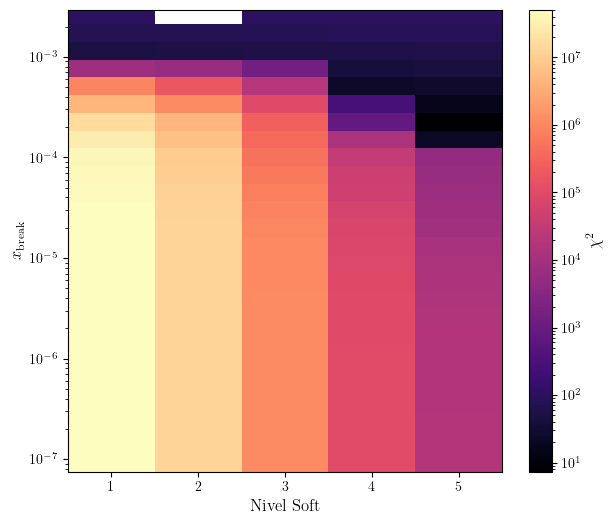

In [555]:
import matplotlib as mpl

niveles_soft = [1, 2, 3, 4, 5]
chi_cuadrado_por_soft = [
    chi_cuadrado_momentos_0_soft_1,
    chi_cuadrado_momentos_0_soft_2,
    chi_cuadrado_momentos_0_soft_3,
    chi_cuadrado_momentos_0_soft_4,
    chi_cuadrado_momentos_0_soft_5,
]
umbrales_por_soft = [
    umbrales_soft_1,
    umbrales_soft_2,
    umbrales_soft_3,
    umbrales_soft_4,
    umbrales_soft_5,
]

umbrales_ref = max(umbrales_por_soft, key=len)

chi_matrix = np.full((len(umbrales_ref), len(niveles_soft)), np.nan)
for col, chi in enumerate(chi_cuadrado_por_soft):
    chi_matrix[:len(chi), col] = chi

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(
    niveles_soft, umbrales_ref, chi_matrix,
    shading='nearest',
    norm=mpl.colors.LogNorm(),
    cmap='magma'
)
plt.colorbar(mesh, label=r'$\chi^2$')
plt.xlabel('Nivel Soft')
plt.ylabel(r'$x_{\mathrm{break}}$')
plt.yscale('log')
plt.xticks(niveles_soft)

## 1.4. Isolated AC2

In [66]:
CUBE_DIR = 'isolated_sub_AC2_N15_width1'

### 1.4.1. Apertura Momentos de Referencia

In [67]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment0_AC2.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment1_AC2.fits'))
moment_1_ref = np.squeeze(hdu[0].data)
moment_1_ref_flat = np.nan_to_num(moment_1_ref).flatten()


hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment2_AC2.fits'))
moment_2_ref = np.squeeze(hdu[0].data)

### 1.4.2. Momentos 0

In [558]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

momentos_0_noisy  = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub')
momentos_0_soft_5 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_5')
momentos_0_soft_4 = cargar_momentos_log('moments_soft_4', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_4')
momentos_0_soft_3 = cargar_momentos_log('moments_soft_3', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_3')
momentos_0_soft_2 = cargar_momentos_log('moments_soft_2', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_2')
momentos_0_soft_1 = cargar_momentos_log('moments_soft_1', 0, IterativeMin, IterativeStep, 'isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_1')

In [559]:
flux_max_val = flux_max('isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_5')
umbrales_soft_5 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_4')
umbrales_soft_4 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_3')
umbrales_soft_3 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC2_N15_width1_noisy_sub_wavelets_iterative_soft_2')
umbrales_soft_2 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC2_N15_width1_noisy_sub')
umbrales_noisy = umbrales_log(flux_max_val, IterativeMin, IterativeStep)


#### 1.4.2.A. RMSE

In [560]:
rmse_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_5.append(rmse_momento_0)

rmse_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_4.append(rmse_momento_0)

rmse_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_3.append(rmse_momento_0)

rmse_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_2.append(rmse_momento_0)

rmse_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_1.append(rmse_momento_0)

rmse_momentos_0_noisy = []
for momento in momentos_0_noisy:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_noisy.append(rmse_momento_0)


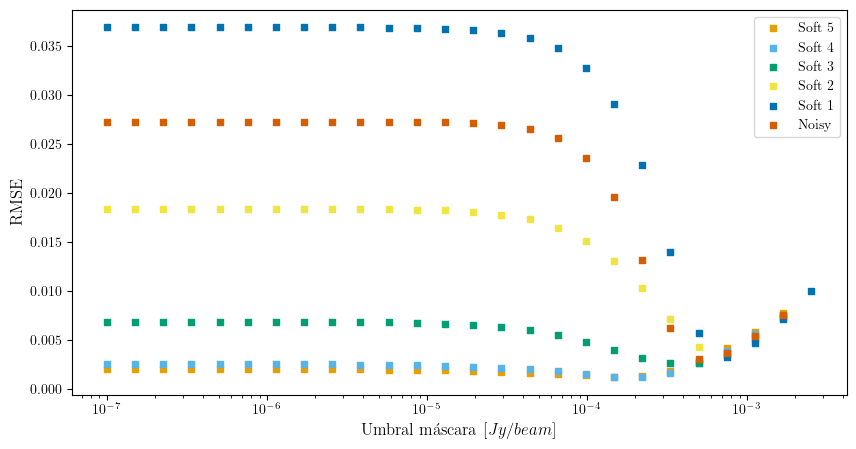

In [561]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, rmse_momentos_0_soft_5, s=15, label='Soft 5', marker='s')
plt.scatter(umbrales_soft_4, rmse_momentos_0_soft_4, s=15, label='Soft 4', marker='s')
plt.scatter(umbrales_soft_3, rmse_momentos_0_soft_3, s=15, label='Soft 3', marker='s')
plt.scatter(umbrales_soft_2, rmse_momentos_0_soft_2, s=15, label='Soft 2', marker='s')
plt.scatter(umbrales_soft_1, rmse_momentos_0_soft_1, s=15, label='Soft 1', marker='s')
plt.scatter(umbrales_noisy, rmse_momentos_0_noisy, s=15, label='Noisy', marker='s')
plt.xlabel('Umbral máscara [$Jy/beam$]')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()

#### 1.4.2.B. Chi Cuadrado

In [562]:
chi_cuadrado_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_5.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_4.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_3.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_2.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_1.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_noisy = []
for momento in momentos_0_noisy:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_noisy.append(chi_cuadrado_momento_0)


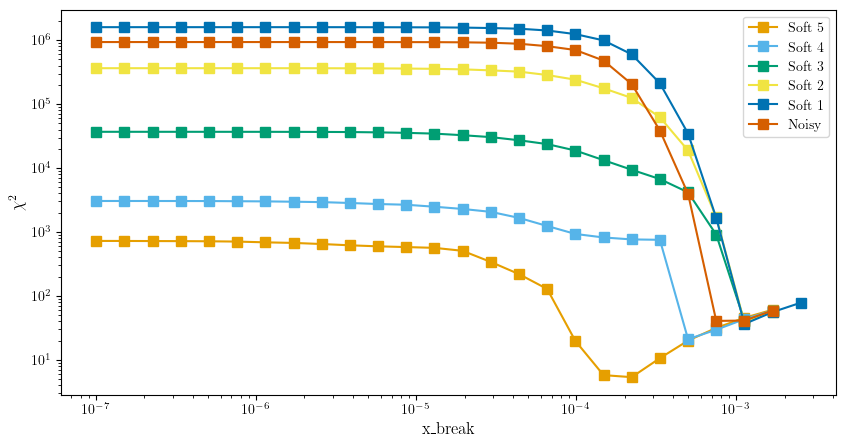

In [564]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s')
plt.errorbar(umbrales_noisy, chi_cuadrado_momentos_0_noisy, ms=7, label='Noisy', marker='s')
plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

([<matplotlib.axis.XTick at 0x12cdf91b0>,
 [Text(1, 0, '$\\mathdefault{1}$'),
  Text(2, 0, '$\\mathdefault{2}$'),
  Text(3, 0, '$\\mathdefault{3}$'),
  Text(4, 0, '$\\mathdefault{4}$'),
  Text(5, 0, '$\\mathdefault{5}$')])

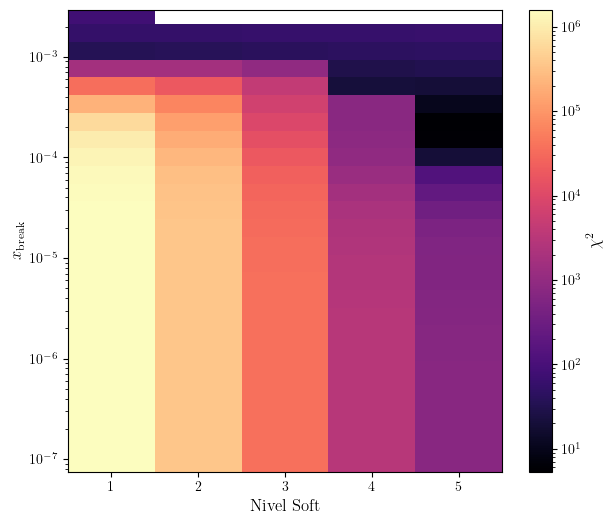

In [565]:
import matplotlib as mpl

niveles_soft = [1, 2, 3, 4, 5]
chi_cuadrado_por_soft = [
    chi_cuadrado_momentos_0_soft_1,
    chi_cuadrado_momentos_0_soft_2,
    chi_cuadrado_momentos_0_soft_3,
    chi_cuadrado_momentos_0_soft_4,
    chi_cuadrado_momentos_0_soft_5,
]
umbrales_por_soft = [
    umbrales_soft_1,
    umbrales_soft_2,
    umbrales_soft_3,
    umbrales_soft_4,
    umbrales_soft_5,
]

umbrales_ref = max(umbrales_por_soft, key=len)

chi_matrix = np.full((len(umbrales_ref), len(niveles_soft)), np.nan)
for col, chi in enumerate(chi_cuadrado_por_soft):
    chi_matrix[:len(chi), col] = chi

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(
    niveles_soft, umbrales_ref, chi_matrix,
    shading='nearest',
    norm=mpl.colors.LogNorm(),
    cmap='magma'
)
plt.colorbar(mesh, label=r'$\chi^2$')
plt.xlabel('Nivel Soft')
plt.ylabel(r'$x_{\mathrm{break}}$')
plt.yscale('log')
plt.xticks(niveles_soft)

## 1.5. Isolated AC1

In [566]:
CUBE_DIR = 'isolated_sub_AC1_N7_width1'

### 1.5.1. Apertura Momentos de Referencia

In [567]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment0_AC1.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment1_AC1.fits'))
moment_1_ref = np.squeeze(hdu[0].data)
moment_1_ref_flat = np.nan_to_num(moment_1_ref).flatten()


hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR, 'moments_ref', 'notnoisy_moment2_AC1.fits'))
moment_2_ref = np.squeeze(hdu[0].data)

### 1.5.2. Momentos 0

In [568]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

#momentos_0_noisy  = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy')
momentos_0_soft_5 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_5')
momentos_0_soft_4 = cargar_momentos_log('moments_soft_4', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_4')
momentos_0_soft_3 = cargar_momentos_log('moments_soft_3', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_3')
momentos_0_soft_2 = cargar_momentos_log('moments_soft_2', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_2')
momentos_0_soft_1 = cargar_momentos_log('moments_soft_1', 0, IterativeMin, IterativeStep, 'isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_1')

In [569]:
flux_max_val = flux_max('isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_5')
umbrales_soft_5 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_4')
umbrales_soft_4 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_3')
umbrales_soft_3 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_2')
umbrales_soft_2 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC1_N7_width1_noisy_wavelets_iterative_soft_1')
umbrales_soft_1 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)



#### 1.5.2.A. RMSE

In [570]:
rmse_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_5.append(rmse_momento_0)

rmse_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_4.append(rmse_momento_0)

rmse_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_3.append(rmse_momento_0)

rmse_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_2.append(rmse_momento_0)

rmse_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    rmse_momento_0 = rmse(momento, moment_0_ref_flat)
    rmse_momentos_0_soft_1.append(rmse_momento_0)


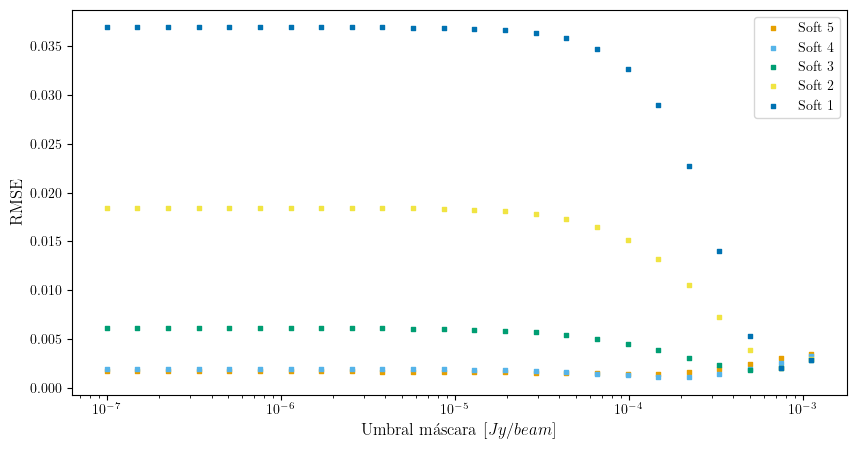

In [571]:
plt.figure(figsize=(10, 5))
plt.scatter(umbrales_soft_5, rmse_momentos_0_soft_5, s=10, label='Soft 5', marker='s')
plt.scatter(umbrales_soft_4, rmse_momentos_0_soft_4, s=10, label='Soft 4', marker='s')
plt.scatter(umbrales_soft_3, rmse_momentos_0_soft_3, s=10, label='Soft 3', marker='s')
plt.scatter(umbrales_soft_2, rmse_momentos_0_soft_2, s=10, label='Soft 2', marker='s')
plt.scatter(umbrales_soft_1, rmse_momentos_0_soft_1, s=10, label='Soft 1', marker='s')
plt.xlabel('Umbral máscara [$Jy/beam$]')
plt.ylabel('RMSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.legend()

#### 1.5.2.B. Chi Cuadrado

In [572]:
chi_cuadrado_momentos_0_soft_5 = []
for momento in momentos_0_soft_5:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_5.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_4 = []
for momento in momentos_0_soft_4:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_4.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_3 = []
for momento in momentos_0_soft_3:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_3.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_2 = []
for momento in momentos_0_soft_2:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_2.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_1 = []
for momento in momentos_0_soft_1:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat)
    chi_cuadrado_momentos_0_soft_1.append(chi_cuadrado_momento_0)



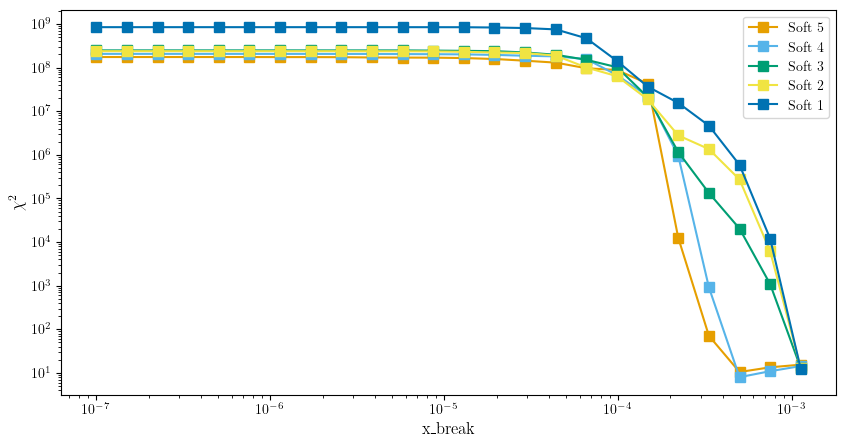

In [574]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5, chi_cuadrado_momentos_0_soft_5, ms=7, label='Soft 5', marker='s')
plt.errorbar(umbrales_soft_4, chi_cuadrado_momentos_0_soft_4, ms=7, label='Soft 4', marker='s')
plt.errorbar(umbrales_soft_3, chi_cuadrado_momentos_0_soft_3, ms=7, label='Soft 3', marker='s')
plt.errorbar(umbrales_soft_2, chi_cuadrado_momentos_0_soft_2, ms=7, label='Soft 2', marker='s')
plt.errorbar(umbrales_soft_1, chi_cuadrado_momentos_0_soft_1, ms=7, label='Soft 1', marker='s')
plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.legend()

([<matplotlib.axis.XTick at 0x12049d900>,
 [Text(1, 0, '$\\mathdefault{1}$'),
  Text(2, 0, '$\\mathdefault{2}$'),
  Text(3, 0, '$\\mathdefault{3}$'),
  Text(4, 0, '$\\mathdefault{4}$'),
  Text(5, 0, '$\\mathdefault{5}$')])

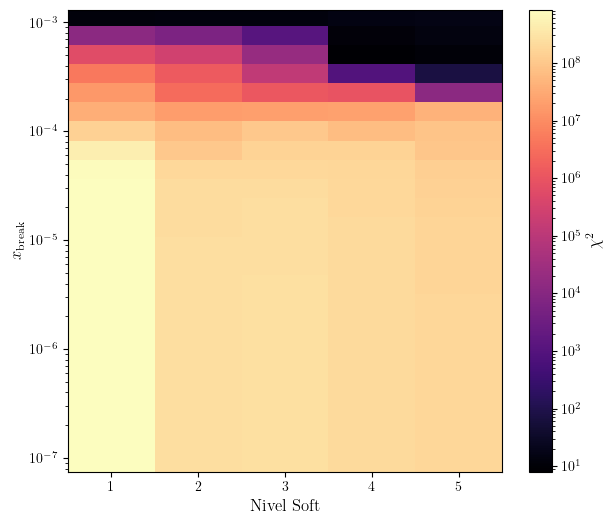

In [428]:
import matplotlib as mpl

niveles_soft = [1, 2, 3, 4, 5]
chi_cuadrado_por_soft = [
    chi_cuadrado_momentos_0_soft_1,
    chi_cuadrado_momentos_0_soft_2,
    chi_cuadrado_momentos_0_soft_3,
    chi_cuadrado_momentos_0_soft_4,
    chi_cuadrado_momentos_0_soft_5,
]
umbrales_por_soft = [
    umbrales_soft_1,
    umbrales_soft_2,
    umbrales_soft_3,
    umbrales_soft_4,
    umbrales_soft_5,
]

umbrales_ref = max(umbrales_por_soft, key=len)

chi_matrix = np.full((len(umbrales_ref), len(niveles_soft)), np.nan)
for col, chi in enumerate(chi_cuadrado_por_soft):
    chi_matrix[:len(chi), col] = chi

plt.figure(figsize=(7, 6))
mesh = plt.pcolormesh(
    niveles_soft, umbrales_ref, chi_matrix,
    shading='nearest',
    norm=mpl.colors.LogNorm(),
    cmap='magma'
)
plt.colorbar(mesh, label=r'$\chi^2$')
plt.xlabel('Nivel Soft')
plt.ylabel(r'$x_{\mathrm{break}}$')
plt.yscale('log')
plt.xticks(niveles_soft)